# BB84 Quantum Key Distribution - No Attacker

This notebook implements the BB84 protocol between Alice and Bob in the absence of an eavesdropper. The aim is to demonstrate that when the quantum channel is not disturbed, Alice and Bob obtain matching key bits at all positions where they used the same basis.

In [ ]:
%pip install qiskit==1.2.4
%pip install qiskit-aer==0.15.1
%pip install pylatexenc==2.10

from qiskit import QuantumCircuit
from qiskit.converters import circuit_to_gate
from qiskit.visualization import array_to_latex
from qiskit.quantum_info import Operator
from qiskit.quantum_info import Statevector
from qiskit import transpile
from qiskit.providers.basic_provider import BasicSimulator
from qiskit.visualization import plot_histogram
from qiskit.circuit import ControlledGate
import math

In [2]:
# Setup
simulator = BasicSimulator()

# Number of qubits Alice will send
N = 20

print(f"Simulating BB84 with N={N} qubits.")

Simulating BB84 with N=20 qubits.


## Choice of Number of Qubits

The BB84 protocol does not require a fixed value of `N`. In this notebook, a small value is chosen so that the intermediate bit strings, basis choices, and key extraction steps remain readable. Since Alice and Bob choose their bases independently at random, only about half of the transmitted qubits are expected to survive basis comparison.

## Quantum Random Number Generation

The assignment requires the random choices in BB84 to be generated from quantum measurement rather than from a classical pseudo-random number generator. For this reason, random bits are produced by preparing the state $|+\rangle$ and measuring it, which gives `0` or `1` with equal probability.

In [3]:
def quantum_random_bit():
  """
  Generate one truly random bit by preparing |+⟩ = (|0⟩+|1⟩)/√2
  and measuring it.
  """
  qc = QuantumCircuit(1, 1)
  qc.h(0)
  qc.measure(0, 0)
  compiled = transpile(qc, simulator)
  result = simulator.run(compiled, shots=1).result()
  return int(list(result.get_counts().keys())[0])

# This calls quantum_random_bit() repeatedly for clarity.
def quantum_random_bits(n):
  """Generate n random bits by calling quantum_random_bit() n times."""
  return [quantum_random_bit() for _ in range(n)]

# Quick sanity check
sample = quantum_random_bits(10)
print("Sample quantum random bits:", sample)

Sample quantum random bits: [0, 0, 1, 1, 0, 1, 0, 1, 0, 1]


## Alice

Alice generates two random binary sequences: one for the data bits and one for the basis choices. Each bit is then encoded as a qubit using either the standard basis or the diagonal basis, following the BB84 encoding rule from the lecture.

In this no-attacker version, Alice sends the prepared qubits directly to Bob through the quantum channel.

In [4]:
alice_bits  = quantum_random_bits(N)
alice_bases = quantum_random_bits(N)

def encoding_circuit(bit, basis):
  """Return Alice's 1-qubit encoding circuit without measurement."""
  qc = QuantumCircuit(1)
  if bit == 1:
      qc.x(0)
  if basis == 1:
      qc.h(0)
  return qc

def alice_prepare_qubit(bit, basis):
  """
  Alice prepares a 1-qubit circuit encoding `bit` in `basis`.

  Standard (basis=0):  bit 0 → |0⟩ (no gates)
                        bit 1 → |1⟩ (X gate)
  Diagonal (basis=1):  bit 0 → |+⟩ (H gate)
                        bit 1 → |−⟩ (X then H)
  """
  qc = QuantumCircuit(1, 1)
  qc.compose(encoding_circuit(bit, basis), inplace=True)
  return qc

# Alice prepares all qubits and places them on the quantum channel
quantum_channel = [alice_prepare_qubit(alice_bits[i], alice_bases[i]) for i in range(N)]

print("=== ALICE ===")
print(f"Bits:   {alice_bits}")
print(f"Bases:  {['S' if b==0 else 'D' for b in alice_bases]}")
print(f"\nAlice has prepared {N} qubits and sent them to Bob.")

=== ALICE ===
Bits:   [0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1]
Bases:  ['D', 'S', 'S', 'S', 'S', 'S', 'D', 'S', 'S', 'S', 'D', 'S', 'S', 'D', 'D', 'D', 'S', 'S', 'D', 'D']

Alice has prepared 20 qubits and sent them to Bob.


## Alice Circuit Example

A single example qubit is displayed below to show how Alice's chosen bit and basis are translated into a circuit, state, and operator form. This makes the encoding step explicit and connects the simulation to the lecture notation.

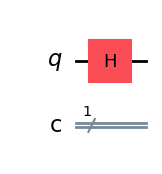

In [5]:
# Show Alice's first prepared qubit as a circuit diagram.
inspection_index = 0
alice_example = quantum_channel[inspection_index]
alice_example.draw("mpl")

In [6]:
# Calculate the state from |0> and display it symbolically.
# Uses the measurement-free version of Alice's same bit and basis.
alice_unitary_example = encoding_circuit(alice_bits[inspection_index], alice_bases[inspection_index])
state = Statevector.from_int(0, 2)
state = state.evolve(alice_unitary_example)
state.draw("latex")

<IPython.core.display.Latex object>

In [7]:
U = Operator(alice_unitary_example)
array_to_latex(U)

<IPython.core.display.Latex object>

## Bob

Bob independently chooses a measurement basis for each received qubit. If Bob uses the same basis as Alice, he should recover Alice's bit exactly; if he uses the other basis, the outcome is random and that position should later be discarded.

In [8]:
bob_bases = quantum_random_bits(N)

def bob_measure_qubit(qubit_circuit, basis):
  """
  Bob measures `qubit_circuit` in `basis`.

  Standard (basis=0): measure in the {|0⟩, |1⟩} basis.
  Diagonal (basis=1): apply H then measure (equivalent to
                      measuring in the {|+⟩, |−⟩} basis).
  Returns the measured bit (0 or 1).
  """
  qc = qubit_circuit.copy()
  if basis == 1:
      qc.h(0)
  qc.measure(0, 0)
  compiled = transpile(qc, simulator)
  result = simulator.run(compiled, shots=1).result()
  return int(list(result.get_counts().keys())[0])

bob_bits = [bob_measure_qubit(quantum_channel[i], bob_bases[i]) for i in range(N)]

print("=== BOB ===")
print(f"Bases:  {['S' if b==0 else 'D' for b in bob_bases]}")
print(f"Bits:   {bob_bits}")

=== BOB ===
Bases:  ['D', 'D', 'D', 'S', 'D', 'S', 'S', 'D', 'D', 'S', 'D', 'S', 'S', 'D', 'S', 'D', 'S', 'D', 'S', 'D']
Bits:   [0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1]


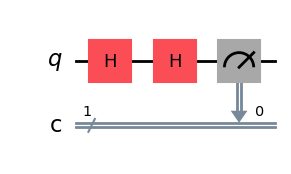

In [9]:
bob_measurement_example = quantum_channel[inspection_index].copy()
if bob_bases[inspection_index] == 1:
    bob_measurement_example.h(0)
bob_measurement_example.measure(0, 0)
bob_measurement_example.draw("mpl")

## Measurement Histogram

The histogram below summarises Bob's observed measurement outcomes across all transmitted qubits. It is included as a measurement summary only and should not be interpreted as the final secret key.

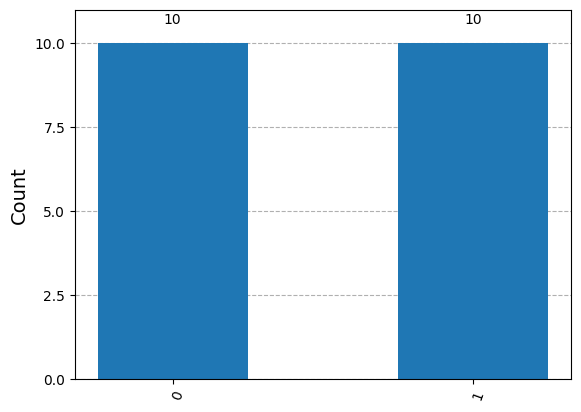

In [10]:
bob_measurement_counts = {
    "0": bob_bits.count(0),
    "1": bob_bits.count(1),
}
plot_histogram(bob_measurement_counts)

## Public Channel: Basic Comparison

Alice and Bob publicly compare only their basis choices, not their bit values. This reveals which positions were measured in compatible bases and therefore which positions can contribute to the sifted key.

In [11]:
matching_indices = [i for i in range(N) if alice_bases[i] == bob_bases[i]]

print("=== PUBLIC CHANNEL: BASIS COMPARISON ===")
print(f"Total qubits sent : {N}")
print(f"Matching positions: {len(matching_indices)}  (expected ~{N//2})")
print(f"Discarded positions: {N - len(matching_indices)}")

=== PUBLIC CHANNEL: BASIS COMPARISON ===
Total qubits sent : 20
Matching positions: 11  (expected ~10)
Discarded positions: 9


## Sample Check

After basis comparison, Alice and Bob publicly compare a sample of the sifted bits. These checked bits are then discarded. In the no-attacker case, the expected error rate in this sample is `0%`, so this step confirms that the protocol has operated correctly before the final key is accepted.

About half of the sifted bits are used for checking so that the sample is large enough to give a meaningful error estimate while still leaving some unrevealed bits for the final key.


In [12]:
def choose_test_positions(matching_positions, fraction=0.5):
    """
    Choose a random subset of the matching-basis positions to reveal publicly.
    These bits are sacrificed for error checking and are not used in the final key.
    """
    if not matching_positions:
        return []

    if len(matching_positions) == 1:
        return [matching_positions[0]]

    test_count = max(1, int(len(matching_positions) * fraction))

    # Generate quantum-random tags so the positions can be shuffled without
    # using Python's classical random module.
    tag_bits = quantum_random_bits(len(matching_positions) * 8)
    tagged_positions = []

    for i, pos in enumerate(matching_positions):
        value = 0
        for j in range(8):
            value += tag_bits[i * 8 + j] << j
        tagged_positions.append((value, pos))

    tagged_positions.sort()
    return [pos for _, pos in tagged_positions[:test_count]]

In [13]:
test_positions = choose_test_positions(matching_indices, fraction=0.5)
test_position_set = set(test_positions)

alice_test_bits = [alice_bits[i] for i in test_positions]
bob_test_bits   = [bob_bits[i] for i in test_positions]

test_errors = sum(a != b for a, b in zip(alice_test_bits, bob_test_bits))
test_error_rate = test_errors / len(alice_test_bits) if alice_test_bits else 0

print("=== SAMPLE CHECK ===")
print(f"Checked positions : {test_positions}")
print(f"Checked bits      : {len(alice_test_bits)}")
print(f"Errors found      : {test_errors}")
print(f"Error rate        : {test_error_rate:.1%}")

=== SAMPLE CHECK ===
Checked positions : [5, 11, 10, 0, 15]
Checked bits      : 5
Errors found      : 0
Error rate        : 0.0%


## Key Extraction

The final key is formed from the sifted positions that were not revealed during the sample check. Because there is no attacker in this simulation, Alice's and Bob's final keys are expected to match exactly.

*If the key bits are uniformly random, private, and used only once, they can be used as a one-time pad, which provides information-theoretic security.*


In [14]:
final_key_indices = [i for i in matching_indices if i not in test_position_set]

alice_key = [alice_bits[i] for i in final_key_indices]
bob_key   = [bob_bits[i]   for i in final_key_indices]

print("=== FINAL SHARED SECRET KEY ===")
print(f"Alice's key : {alice_key}")
print(f"Bob's key   : {bob_key}")
print()

if alice_key == bob_key:
  print(f"Keys MATCH! Final key length: {len(alice_key)} bits.")
  print("Alice and Bob can accept this as their shared secret key.")
else:
  # Count positions where Alice and Bob's bits differ (True=1, False=0).
  mismatches = sum(a != b for a, b in zip(alice_key, bob_key))
  print(f"Keys do NOT match ({mismatches} mismatches).")


=== FINAL SHARED SECRET KEY ===
Alice's key : [0, 1, 1, 0, 0, 1]
Bob's key   : [0, 1, 1, 0, 0, 1]

Keys MATCH! Final key length: 6 bits.
Alice and Bob can accept this as their shared secret key.


## Summary

The no-attacker BB84 simulation is successful if the sample check shows zero disagreement and the remaining unrevealed key bits agree exactly. This demonstrates the normal operation of the protocol in an undisturbed channel.

In [15]:
print("===== BB84 PROTOCOL SUMMARY (No Attacker) =====")
print(f"Qubits sent by Alice    : {N}")
print(f"Basis matches           : {len(matching_indices)} (~{100*len(matching_indices)/N:.0f}%)")
print(f"Checked sample size     : {len(alice_test_bits)}")
print(f"Sample error rate       : {test_error_rate:.1%}")
print(f"Final key length        : {len(alice_key)} bits")
print(f"Final keys agree        : {alice_key == bob_key}")
print()
print("Protocol complete. In the no-attacker case, the checked error rate is 0% and the shared key can be used as a one-time pad.")

===== BB84 PROTOCOL SUMMARY (No Attacker) =====
Qubits sent by Alice    : 20
Basis matches           : 11 (~55%)
Checked sample size     : 5
Sample error rate       : 0.0%
Final key length        : 6 bits
Final keys agree        : True

Protocol complete. In the no-attacker case, the checked error rate is 0% and the shared key can be used as a one-time pad.
